In [1]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [3]:
df.columns

Index(['show_id', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'type'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [5]:
df.isnull().sum()

show_id            0
title              0
director        1901
cast             556
country          427
date_added       642
release_year       0
rating            10
duration           0
listed_in          0
description        0
type               0
dtype: int64

In [6]:
df['director'] = df['director'].fillna("unknown")  #filling the not values to "unknown" values
df['cast'] = df['cast'].fillna("unknown")
df['country'] = df['country'].fillna("unknown")

In [30]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')  #those values remain because:They were already missing (NaN)

In [12]:
df['rating'] = df['rating'].fillna("Not rated")

In [13]:
df.isnull().sum()

show_id           0
title             0
director          0
cast              0
country           0
date_added      642
release_year      0
rating            0
duration          0
listed_in         0
description       0
type              0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['type'].value_counts()  #Counts how many of each unique value appear

type
Movie      3939
TV Show    1898
Name: count, dtype: int64

In [22]:
df_valid.columns.tolist()  #to see all available column names:

['show_id',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description',
 'type']

In [31]:
df['year_added'] = df['date_added'].dt.year   #adding year column

In [33]:
df_valid = df.dropna(subset=['date_added']) #drop date added 
df_valid.groupby('year_added').size()   #Groups all rows that have the same date and Counts how many rows in each group

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       7
2013.0       9
2014.0      19
2015.0      74
2016.0     412
2017.0    1184
2018.0    1629
2019.0    1843
dtype: int64

In [25]:
df['listed_in'].value_counts().head(10)  #Top Genres

listed_in
Documentaries                                       297
Stand-Up Comedy                                     265
Dramas, International Movies                        238
Dramas, Independent Movies, International Movies    170
Comedies, Dramas, International Movies              157
Kids' TV                                            153
Documentaries, International Movies                 147
Children & Family Movies                            115
Comedies, International Movies                      113
Children & Family Movies, Comedies                  110
Name: count, dtype: int64

In [26]:
df['country'].value_counts().head(10)  #Top countries

country
United States     1907
India              697
unknown            427
United Kingdom     336
Japan              168
Canada             139
South Korea        133
Spain              113
France              85
Mexico              80
Name: count, dtype: int64

In [27]:
df['rating'].value_counts()

rating
TV-MA        1937
TV-14        1593
TV-PG         678
R             439
PG-13         227
NR            218
PG            160
TV-Y7         156
TV-G          147
TV-Y          139
TV-Y7-FV       92
G              32
Not rated      10
UR              7
NC-17           2
Name: count, dtype: int64

In [ ]:
Netflix content additions increased significantly over time, especially around 2019, indicating rapid platform expansion.

In [34]:
df.columns

Index(['show_id', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'type', 'year_added'],
      dtype='object')

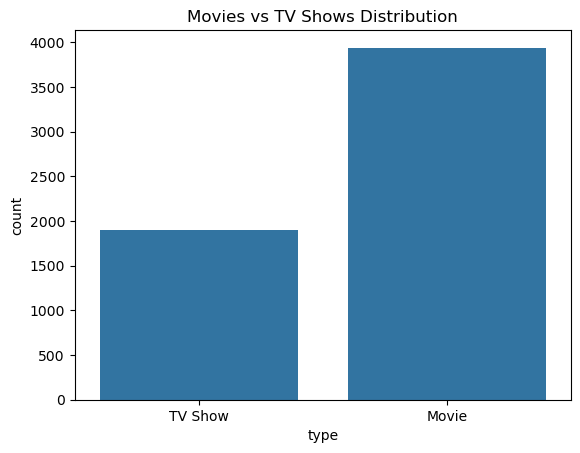

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows Distribution")
plt.show()

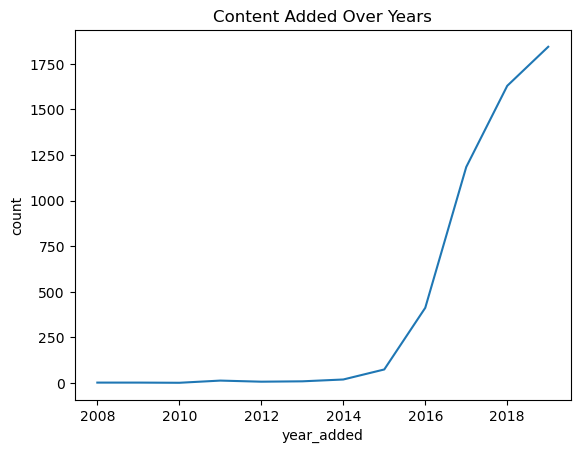

In [36]:
year_data = df_valid.groupby('year_added').size().reset_index(name='count')

sns.lineplot(x='year_added', y='count', data=year_data)
plt.title("Content Added Over Years")
plt.show()

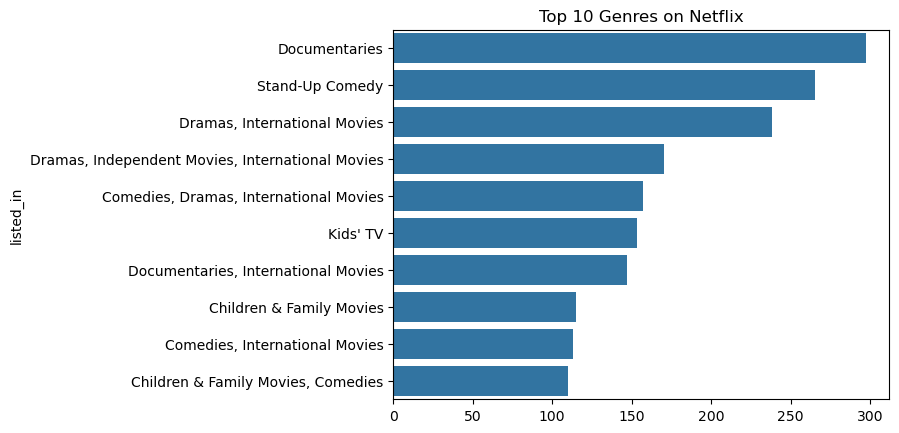

In [37]:
top_genres = df['listed_in'].value_counts().head(10)

sns.barplot(x = top_genres.values, y = top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.show()

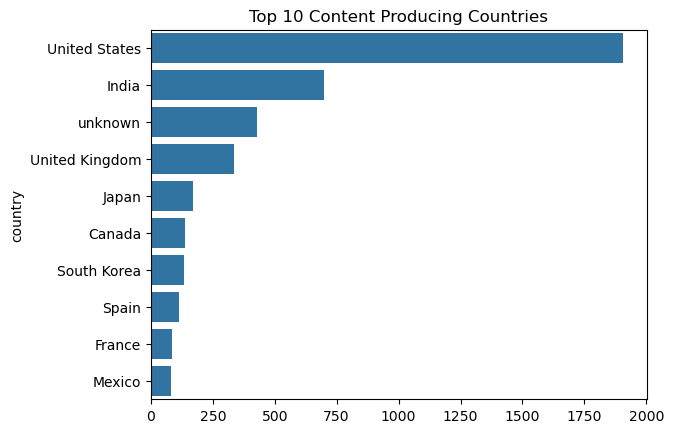

In [38]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.show()

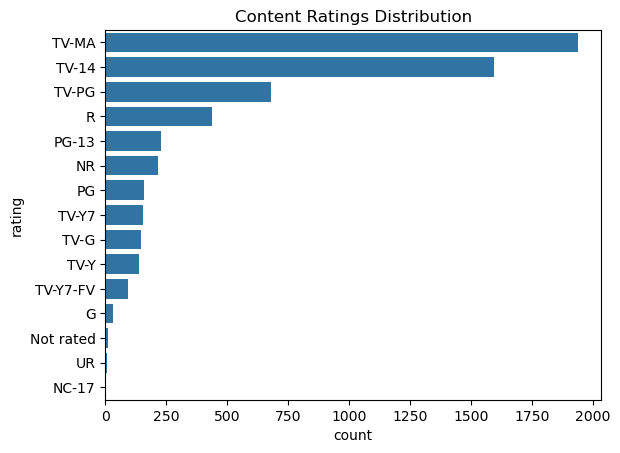

In [43]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index )
plt.title("Content Ratings Distribution")
plt.show()

In [ ]:
#Movies dominate Netflix content compared to TV shows, indicating a larger focus on movie-based content.

In [ ]:
#Netflix content increased significantly after 2015, with peak additions around recent years, showing rapid platform expansion.

In [ ]:
#Documentaries and international drama genres are highly popular, reflecting audience interest in informative and global content.

In [ ]:
#The United States contributes the highest content, followed by India, making them key content-producing countries.

In [ ]:
#Most content falls under TV-MA and TV-14, indicating a focus on mature and teen audiences.

In [46]:
# Find the "Flying Fortress" error
df_valid[df_valid['release_year'].astype(str).str.contains('Flying', na=False)]

# OR check all weird values in release_year
df_valid['release_year'].unique()

array([2019, 2018, 2016, 2017, 2001, 2008, 1980, 1973, 2012, 1987, 2002,
       2015, 2013, 1996, 1992, 2007, 2009, 1995, 2014, 1968, 2010, 1999,
       2011, 2000, 1974, 1997, 1993, 2006, 2005, 2003, 2004, 2020, 1998,
       1960, 1958, 1965, 1956, 1978, 1990, 1976, 1962, 1955, 1972, 1991,
       1988, 1989, 1975, 1985, 1984, 1970, 1994, 1982, 1983, 1967, 1981,
       1979, 1986, 1925, 1946, 1977, 1959, 1966, 1971, 1969, 1945, 1942,
       1944, 1947, 1943, 1954])

In [49]:
# See what's in duration
df_valid['duration'].value_counts().head(20)

# Look specifically for "Flying"
df_valid[df_valid['duration'].str.contains('Flying', na=False, case=False)]

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type,year_added,duration_value,duration_unit


In [50]:
# Export your entire cleaned dataframe to CSV
df_valid.to_csv('netflix_dashboard_ready.csv', index=False)

# Confirm it saved and show location
import os
print("✅ File saved successfully!")
print("📁 Location:", os.getcwd())
print("📄 Filename: netflix_dashboard_ready.csv")

✅ File saved successfully!
📁 Location: C:\Users\kiran\Project 2
📄 Filename: netflix_dashboard_ready.csv


In [51]:
# See all column names and first few rows
print("Column names:", df_valid.columns.tolist())
print("\nFirst 5 rows:")
print(df_valid[['type', 'year_added', 'release_year']].head(10))

Column names: ['show_id', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'type', 'year_added', 'duration_value', 'duration_unit']

First 5 rows:
       type  year_added  release_year
0   TV Show      2019.0          2019
1     Movie      2019.0          2019
2     Movie      2019.0          2019
3     Movie      2019.0          2019
5     Movie      2019.0          2018
6     Movie      2019.0          2019
7     Movie      2019.0          2016
9     Movie      2019.0          2018
10    Movie      2019.0          2018
11  TV Show      2019.0          2019
